# 03 — Control de calidad de productos anuales Landsat 8/9

**Repositorio:** `lst-barranquilla-suhi-deep-learning`  
**Área de estudio:** Barranquilla, Colombia  
**Periodo operativo:** 2013–2025  
**Entrada:** productos anuales Landsat 8/9 generados por `02_preprocessing_lst_indices.ipynb`

Este notebook ejecuta la etapa de control de calidad posterior a la generación de composiciones anuales de LST e índices espectrales.

## Objetivos principales

1. Verificar la completitud de los productos anuales crudos generados por el Notebook 02.
2. Revisar la geometría espacial frente a la grilla canónica del dominio de modelado.
3. Auditar píxeles válidos y rangos de valores por variable y año.
4. Aplicar la máscara terrestre estructural T30, si está habilitada.
5. Aplicar el dominio terrestre final refinado, si los insumos auxiliares están disponibles.
6. Construir una máscara común multivariable para cada año.
7. Exportar reportes CSV ligeros que pueden ser revisados por evaluadores.
8. Generar salidas gráficas de auditoría para la máscara final, la LST anual y la cobertura observacional.

## Nota metodológica

Este notebook no consulta Google Earth Engine y no recalcula productos Landsat. Opera sobre los GeoTIFF locales o almacenados en Google Drive generados por el Notebook 02.

El notebook conserva los identificadores históricos `EXP10Bv3`, `EXP10Bv4T30`, `EXP10Bv5` y `EXP10Bv6` para mantener trazabilidad y compatibilidad con etapas previas del procesamiento.



In [1]:
# ============================================================
# CELDA 1 — Instalación opcional e importación de librerías
# ============================================================

import sys
import subprocess
from pathlib import Path

try:
    import rasterio
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])

try:
    import scipy
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy"])

import json
import shutil
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from rasterio.warp import reproject
from scipy import ndimage as ndi

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Imports completed.")
print("Running in Colab:", IN_COLAB)



Imports completed.
Running in Colab: True


In [2]:
# ============================================================
# CELDA 2 — Montar Google Drive y configurar rutas del proyecto
# ============================================================

if IN_COLAB:
    drive.mount("/content/drive")

# ------------------------------------------------------------------
# RUTA EDITABLE POR EL USUARIO
# ------------------------------------------------------------------
# This path points to the external working directory where large rasters
# are stored. It is intentionally outside the GitHub repository.
#
# The directory name may still contain 2013_2026 for historical reasons,
# but this notebook only processes the 2013–2025 operational period.
# ------------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling")

# Main input from Notebook 02.
V3_DIR = PROJECT_DIR / "03_annual_raw_composites" / "v3_expanded_raw"

# Intermediate and final local products generated by this notebook.
V4_T30_DIR = PROJECT_DIR / "03_annual_raw_composites" / "v4_T30_structural_land"
V5_DIR = PROJECT_DIR / "03_annual_raw_composites" / "v5_final_domain"
V6_DIR = PROJECT_DIR / "03_annual_raw_composites" / "v6_common_valid_mask"

# Quality-control reports.
OUT_DIR = PROJECT_DIR / "00_documentation" / "quality_control" / "03_quality_control_2013_2025"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for d in [V4_T30_DIR, V5_DIR, V6_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"PROJECT_DIR does not exist: {PROJECT_DIR}")
if not V3_DIR.exists():
    raise FileNotFoundError(
        "No existe V3_DIR. Ejecute primero el Notebook 02 y consolide los productos anuales.\n"
        f"Ruta esperada: {V3_DIR}"
    )

print("PROJECT_DIR:", PROJECT_DIR)
print("V3_DIR:", V3_DIR)
print("V4_T30_DIR:", V4_T30_DIR)
print("V5_DIR:", V5_DIR)
print("V6_DIR:", V6_DIR)
print("OUT_DIR:", OUT_DIR)


Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling
V3_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/03_annual_raw_composites/v3_expanded_raw
V4_T30_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/03_annual_raw_composites/v4_T30_structural_land
V5_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/03_annual_raw_composites/v5_final_domain
V6_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/03_annual_raw_composites/v6_common_valid_mask
OUT_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025


In [3]:
# ============================================================
# CELL 3 — Configuration
# ============================================================

START_YEAR = 2013
END_YEAR = 2025
YEARS = list(range(START_YEAR, END_YEAR + 1))

SPECTRAL_VARS = ["NDVI", "NDMI", "NDBI", "UI", "SAVI", "BSI"]
CONTINUOUS_VARS = SPECTRAL_VARS + ["LST"]
NOBS_VARS = ["n_obs_indices", "n_obs_LST"]
ALL_VARS = SPECTRAL_VARS + ["LST"] + NOBS_VARS

EXPECTED_FILES_PER_YEAR = len(ALL_VARS)
EXPECTED_TOTAL_FILES = len(YEARS) * EXPECTED_FILES_PER_YEAR

# Processing switches.
# Set APPLY_FINAL_DOMAIN = False if the required auxiliary land-count mask is not available yet.
APPLY_STRUCTURAL_T30_MASK = True
APPLY_FINAL_DOMAIN = True
BUILD_COMMON_VALID_MASK = True

# Final-domain support year. It must be inside the operational period.
SUPPORT_YEAR = 2025

# Conservative rule used for directed hydro-residual exclusion.
HYDRO_BUFFER_PX = 2
MIN_STRUCTURAL_WATER_COMPONENT_PX = 500
NOBS_LOW_MAX = 18
LAND_COUNT_WEAK_MAX = 45

# Soft physical/radiometric ranges for QC flags.
VALUE_RANGES = {
    "NDVI": (-1.0, 1.0),
    "NDMI": (-1.0, 1.0),
    "NDBI": (-1.0, 1.0),
    "UI": (-1.0, 1.0),
    "SAVI": (-1.5, 1.5),
    "BSI": (-1.0, 1.0),
    "LST": (15.0, 80.0),
}

print("Years:", YEARS)
print("Variables:", ALL_VARS)
print("Expected files per year:", EXPECTED_FILES_PER_YEAR)
print("Expected total files:", EXPECTED_TOTAL_FILES)
print("APPLY_STRUCTURAL_T30_MASK:", APPLY_STRUCTURAL_T30_MASK)
print("APPLY_FINAL_DOMAIN:", APPLY_FINAL_DOMAIN)
print("BUILD_COMMON_VALID_MASK:", BUILD_COMMON_VALID_MASK)


Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Variables: ['NDVI', 'NDMI', 'NDBI', 'UI', 'SAVI', 'BSI', 'LST', 'n_obs_indices', 'n_obs_LST']
Expected files per year: 9
Expected total files: 117
APPLY_STRUCTURAL_T30_MASK: True
APPLY_FINAL_DOMAIN: True
BUILD_COMMON_VALID_MASK: True


In [4]:
# ============================================================
# CELDA 4 — Resolver ráster de referencia y máscaras auxiliares
# ============================================================

def resolve_first_existing(candidates, label, required=True):
    for p in candidates:
        p = Path(p)
        if p.exists():
            print(f"{label}: {p}")
            return p
    msg = f"No se encontró {label}. Rutas revisadas:\n" + "\n".join(str(p) for p in candidates)
    if required:
        raise FileNotFoundError(msg)
    print("ADVERTENCIA:", msg)
    return None

MODEL_DOMAIN_REFERENCE = resolve_first_existing([
    PROJECT_DIR / "01_aoi_reference" / "canonical_grid_reference.tif",
    PROJECT_DIR / "01_aoi_reference" / "reference_grid" / "model_domain_reference.tif",
    PROJECT_DIR / "02_reference" / "canonical_grid_reference.tif",
], "MODEL_DOMAIN_REFERENCE", required=True)

T30_MASK = resolve_first_existing([
    PROJECT_DIR / "04_quality_masks" / "land_domain_T30" / "land_domain_static_T30.tif",
], "T30_MASK", required=APPLY_STRUCTURAL_T30_MASK)

LAND_COUNT_PATH = resolve_first_existing([
    PROJECT_DIR / "04_quality_masks" / "land_domain_T30" / "land_strict_count_from_old_masks.tif",
], "LAND_COUNT_PATH", required=False)

if LAND_COUNT_PATH is None:
    candidates = sorted(PROJECT_DIR.rglob("land_strict_count_from_old_masks.tif"))
    if candidates:
        LAND_COUNT_PATH = candidates[0]
        print("LAND_COUNT_PATH found by recursive search:", LAND_COUNT_PATH)

if APPLY_FINAL_DOMAIN and LAND_COUNT_PATH is None:
    raise FileNotFoundError(
        "APPLY_FINAL_DOMAIN is True, but land_strict_count_from_old_masks.tif was not found. "
        "Set APPLY_FINAL_DOMAIN = False or provide the auxiliary mask."
    )

with rasterio.open(MODEL_DOMAIN_REFERENCE) as ref:
    REF_PROFILE = ref.profile.copy()
    REF_CRS = ref.crs
    REF_TRANSFORM = ref.transform
    REF_HEIGHT = ref.height
    REF_WIDTH = ref.width
    REF_SHAPE = (ref.height, ref.width)
    REF_BOUNDS = ref.bounds

print("\nGeometría canónica:")
print("shape    :", REF_SHAPE)
print("crs      :", REF_CRS)
print("transform:", REF_TRANSFORM)
print("bounds   :", REF_BOUNDS)


MODEL_DOMAIN_REFERENCE: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/01_aoi_reference/reference_grid/model_domain_reference.tif
T30_MASK: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/04_quality_masks/land_domain_T30/land_domain_static_T30.tif
LAND_COUNT_PATH: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/04_quality_masks/land_domain_T30/land_strict_count_from_old_masks.tif

Geometría canónica:
shape    : (1115, 1257)
crs      : EPSG:32618
transform: | 30.00, 0.00, 495735.00|
| 0.00,-30.00, 1230045.00|
| 0.00, 0.00, 1.00|
bounds   : BoundingBox(left=495735.0, bottom=1196595.0, right=533445.0, top=1230045.0)


In [5]:
# ============================================================
# CELL 5 — File naming and raster utility functions
# ============================================================

def expected_filename(version: str, varname: str, year: int) -> str:
    """Return the expected filename for a product version, variable and year."""
    if version == "v4":
        prefix = "EXP10Bv4T30"
    else:
        prefix = f"EXP10B{version}"

    if varname == "LST":
        return f"{prefix}_LST_median_{year}.tif"
    if varname == "n_obs_indices":
        return f"{prefix}_n_obs_indices_{year}.tif"
    if varname == "n_obs_LST":
        return f"{prefix}_n_obs_LST_{year}.tif"
    return f"{prefix}_{varname}_median_{year}.tif"


def expected_files(version: str):
    return [expected_filename(version, v, y) for y in YEARS for v in ALL_VARS]


def parse_year_var_from_name(name: str):
    stem = name.replace(".tif", "")
    year = int(stem.split("_")[-1])

    if "n_obs_indices" in name:
        varname = "n_obs_indices"
    elif "n_obs_LST" in name:
        varname = "n_obs_LST"
    elif "LST_median" in name:
        varname = "LST"
    else:
        # EXP10Bv3_NDVI_median_2013
        varname = stem.split("_")[1]
    return year, varname


def same_bounds(a, b) -> bool:
    return (
        np.isclose(a.left, b.left) and
        np.isclose(a.bottom, b.bottom) and
        np.isclose(a.right, b.right) and
        np.isclose(a.top, b.top)
    )


def geom_equal_to_reference(shape, crs, transform, bounds) -> bool:
    return (
        shape == REF_SHAPE and
        crs == REF_CRS and
        transform == REF_TRANSFORM and
        same_bounds(bounds, REF_BOUNDS)
    )


def read_valid_mask(path: Path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata
        shape = (src.height, src.width)
        crs = src.crs
        transform = src.transform
        bounds = src.bounds
        dtype = src.dtypes[0]

    if nodata is not None:
        valid = arr != nodata
    else:
        if np.issubdtype(arr.dtype, np.floating):
            valid = np.isfinite(arr)
        else:
            valid = np.ones(arr.shape, dtype=bool)

    if np.issubdtype(arr.dtype, np.floating):
        valid = valid & np.isfinite(arr)

    return valid, shape, crs, transform, bounds, dtype, nodata


def array_stats(arr, nodata=None, varname=None):
    arr = np.asarray(arr)

    if nodata is not None:
        valid = arr != nodata
    else:
        if np.issubdtype(arr.dtype, np.floating):
            valid = np.isfinite(arr)
        else:
            valid = np.ones(arr.shape, dtype=bool)

    if np.issubdtype(arr.dtype, np.floating):
        valid = valid & np.isfinite(arr)

    vals = arr[valid]
    out = {
        "valid_pixels": int(valid.sum()),
        "valid_fraction": float(valid.sum() / valid.size),
        "min": np.nan,
        "p01": np.nan,
        "p05": np.nan,
        "p50": np.nan,
        "p95": np.nan,
        "p99": np.nan,
        "max": np.nan,
        "out_of_range_pixels": 0,
        "out_of_range_fraction_valid": 0.0,
    }

    if vals.size > 0:
        vals_float = vals.astype("float64")
        out.update({
            "min": float(np.nanmin(vals_float)),
            "p01": float(np.nanpercentile(vals_float, 1)),
            "p05": float(np.nanpercentile(vals_float, 5)),
            "p50": float(np.nanpercentile(vals_float, 50)),
            "p95": float(np.nanpercentile(vals_float, 95)),
            "p99": float(np.nanpercentile(vals_float, 99)),
            "max": float(np.nanmax(vals_float)),
        })

        if varname in VALUE_RANGES:
            lo, hi = VALUE_RANGES[varname]
            bad = (vals_float < lo) | (vals_float > hi)
            out["out_of_range_pixels"] = int(bad.sum())
            out["out_of_range_fraction_valid"] = float(bad.sum() / vals_float.size)

    return out


def transform_same_origin_resolution(src_transform, ref_transform, atol=1e-9):
    return (
        abs(src_transform.a - ref_transform.a) <= atol and
        abs(src_transform.e - ref_transform.e) <= atol and
        abs(src_transform.c - ref_transform.c) <= atol and
        abs(src_transform.f - ref_transform.f) <= atol and
        abs(src_transform.b - ref_transform.b) <= atol and
        abs(src_transform.d - ref_transform.d) <= atol
    )


def read_on_reference_grid(src_path: Path):
    """Read a raster and place it on the canonical reference grid."""
    with rasterio.open(src_path) as src:
        arr = src.read(1)
        src_nodata = src.nodata
        src_crs = src.crs
        src_transform = src.transform
        src_height = src.height
        src_width = src.width
        is_nobs = "n_obs" in src_path.name

        same_grid = (
            src_crs == REF_CRS and
            src_transform == REF_TRANSFORM and
            src_height == REF_HEIGHT and
            src_width == REF_WIDTH
        )

        same_origin_resolution = (
            src_crs == REF_CRS and
            transform_same_origin_resolution(src_transform, REF_TRANSFORM) and
            src_height == REF_HEIGHT
        )

        if same_grid:
            out = arr.copy()
            method = "direct_read"

        elif same_origin_resolution:
            if is_nobs:
                out = np.zeros(REF_SHAPE, dtype=arr.dtype)
            else:
                out = np.full(REF_SHAPE, -9999.0, dtype="float32")
            rows = min(REF_HEIGHT, src_height)
            cols = min(REF_WIDTH, src_width)
            out[:rows, :cols] = arr[:rows, :cols]
            method = "column_crop_or_padding"

        else:
            if is_nobs:
                out = np.zeros(REF_SHAPE, dtype=arr.dtype)
                resampling = Resampling.nearest
                dst_nodata = 0
            else:
                out = np.full(REF_SHAPE, -9999.0, dtype="float32")
                resampling = Resampling.bilinear
                dst_nodata = -9999.0
                arr = arr.astype("float32")
                if src_nodata is not None:
                    arr[arr == src_nodata] = -9999.0

            reproject(
                source=arr,
                destination=out,
                src_transform=src_transform,
                src_crs=src_crs,
                src_nodata=src_nodata if src_nodata is not None else None,
                dst_transform=REF_TRANSFORM,
                dst_crs=REF_CRS,
                dst_nodata=dst_nodata,
                resampling=resampling,
            )
            method = "reproject"

    return out, src_nodata, is_nobs, method


def write_raster(path: Path, arr, dtype, nodata, compress="deflate"):
    profile = REF_PROFILE.copy()
    profile.update(dtype=dtype, count=1, nodata=nodata, compress=compress)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr.astype(dtype), 1)


In [6]:
# ============================================================
# CELL 6 — QC of V3 annual raw products from Notebook 02
# ============================================================

expected_v3 = expected_files("v3")
found_v3 = sorted([p.name for p in V3_DIR.glob("EXP10Bv3_*.tif")])
missing_v3 = [f for f in expected_v3 if f not in found_v3]
extra_v3 = [f for f in found_v3 if f not in expected_v3]

print("V3 directory:", V3_DIR)
print("Expected V3 files:", len(expected_v3))
print("Found V3 files   :", len(found_v3))
print("Missing V3 files :", len(missing_v3))
print("Extra V3 files   :", len(extra_v3))

file_rows = []
for fname in expected_v3:
    year, varname = parse_year_var_from_name(fname)
    path = V3_DIR / fname
    file_rows.append({"version": "v3", "year": year, "variable": varname, "file": fname, "path": str(path), "exists": path.exists()})

v3_file_check_df = pd.DataFrame(file_rows)
v3_file_check_csv = OUT_DIR / "03_qc_v3_file_existence_2013_2025.csv"
v3_file_check_df.to_csv(v3_file_check_csv, index=False)

if missing_v3:
    display(pd.DataFrame({"missing_file": missing_v3}))
    raise FileNotFoundError("Missing V3 files. Run Notebook 02 and consolidate exports before continuing.")

if extra_v3:
    print("\nADVERTENCIA: se encontraron archivos V3 adicionales y no serán procesados automáticamente. Primeros 20:")
    for f in extra_v3[:20]:
        print("  ", f)

print("V3 file-existence report:", v3_file_check_csv)
display(v3_file_check_df.head())


V3 directory: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/03_annual_raw_composites/v3_expanded_raw
Expected V3 files: 117
Found V3 files   : 126
Missing V3 files : 0
Extra V3 files   : 9

ADVERTENCIA: se encontraron archivos V3 adicionales y no serán procesados automáticamente. Primeros 20:
   EXP10Bv3_BSI_median_2026.tif
   EXP10Bv3_LST_median_2026.tif
   EXP10Bv3_NDBI_median_2026.tif
   EXP10Bv3_NDMI_median_2026.tif
   EXP10Bv3_NDVI_median_2026.tif
   EXP10Bv3_SAVI_median_2026.tif
   EXP10Bv3_UI_median_2026.tif
   EXP10Bv3_n_obs_LST_2026.tif
   EXP10Bv3_n_obs_indices_2026.tif
V3 file-existence report: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/03_qc_v3_file_existence_2013_2025.csv


,version,year,variable,file,path,exists
0,v3,2013,NDVI,EXP10Bv3_NDVI_median_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True
1,v3,2013,NDMI,EXP10Bv3_NDMI_median_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True
2,v3,2013,NDBI,EXP10Bv3_NDBI_median_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True
3,v3,2013,UI,EXP10Bv3_UI_median_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True
4,v3,2013,SAVI,EXP10Bv3_SAVI_median_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True


In [7]:
# ============================================================
# CELL 7 — V3 geometry and value-range audit
# ============================================================

v3_audit_rows = []

for i, fname in enumerate(expected_v3, start=1):
    path = V3_DIR / fname
    year, varname = parse_year_var_from_name(fname)

    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata
        shape = (src.height, src.width)
        crs = src.crs
        transform = src.transform
        bounds = src.bounds
        dtype = src.dtypes[0]

    geom_ref_ok = geom_equal_to_reference(shape, crs, transform, bounds)
    stats = array_stats(arr, nodata=nodata, varname=varname)

    v3_audit_rows.append({
        "version": "v3",
        "year": year,
        "variable": varname,
        "file": fname,
        "shape": str(shape),
        "crs": str(crs),
        "transform": str(transform),
        "bounds": str(bounds),
        "dtype": dtype,
        "nodata": nodata,
        "geom_ref_ok": bool(geom_ref_ok),
        **stats,
    })

    if i % 15 == 0 or i == len(expected_v3):
        print(f"Audited V3 files: {i}/{len(expected_v3)}")

v3_audit_df = pd.DataFrame(v3_audit_rows).sort_values(["year", "variable"]).reset_index(drop=True)
v3_audit_csv = OUT_DIR / "03_qc_v3_geometry_value_audit_2013_2025.csv"
v3_audit_df.to_csv(v3_audit_csv, index=False)

print("V3 geometry/value audit:", v3_audit_csv)
print("All V3 geometries equal reference:", bool(v3_audit_df["geom_ref_ok"].all()))
print("Total out-of-range pixels:", int(v3_audit_df["out_of_range_pixels"].sum()))
display(v3_audit_df.head(20))


Audited V3 files: 15/117
Audited V3 files: 30/117
Audited V3 files: 45/117
Audited V3 files: 60/117
Audited V3 files: 75/117
Audited V3 files: 90/117
Audited V3 files: 105/117
Audited V3 files: 117/117
V3 geometry/value audit: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/03_qc_v3_geometry_value_audit_2013_2025.csv
All V3 geometries equal reference: False
Total out-of-range pixels: 0


,version,year,variable,file,shape,crs,transform,bounds,dtype,nodata,geom_ref_ok,valid_pixels,valid_fraction,min,p01,p05,p50,p95,p99,max,out_of_range_pixels,out_of_range_fraction_valid
0,v3,2013,BSI,EXP10Bv3_BSI_median_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,933333,0.664869,-0.615724,-0.477652,-0.388746,-0.168667,0.098862,0.137722,0.287650,0,0.0
1,v3,2013,LST,EXP10Bv3_LST_median_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,933954,0.665311,15.028356,28.498773,30.124042,34.446128,41.972608,44.023420,48.986385,0,0.0
2,v3,2013,NDBI,EXP10Bv3_NDBI_median_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,933708,0.665136,-0.769921,-0.563024,-0.475761,-0.245938,0.045494,0.106748,0.266163,0,0.0
3,v3,2013,NDMI,EXP10Bv3_NDMI_median_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,933708,0.665136,-0.266163,-0.106748,-0.045494,0.245938,0.475761,0.563024,0.769921,0,0.0
4,v3,2013,NDVI,EXP10Bv3_NDVI_median_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,933751,0.665167,-0.365795,0.105051,0.223492,0.680030,0.842151,0.865075,0.913389,0,0.0
5,v3,2013,SAVI,EXP10Bv3_SAVI_median_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,933954,0.665311,-0.105812,0.061240,0.140890,0.437954,0.595583,0.637594,0.757729,0,0.0
6,v3,2013,UI,EXP10Bv3_UI_median_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,933594,0.665055,-0.881973,-0.809739,-0.739881,-0.525588,-0.084378,0.008108,0.227713,0,0.0
7,v3,2013,n_obs_LST,EXP10Bv3_n_obs_LST_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",uint16,None,False,1403785,1.000000,0.000000,0.000000,0.000000,7.000000,10.000000,11.000000,13.000000,0,0.0
8,v3,2013,n_obs_indices,EXP10Bv3_n_obs_indices_2013.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",uint16,None,False,1403785,1.000000,0.000000,0.000000,0.000000,7.000000,10.000000,11.000000,13.000000,0,0.0
9,v3,2014,BSI,EXP10Bv3_BSI_median_2014.tif,"(1115, 1259)",EPSG:32618,"| 30.00, 0.00, 495735.00|\n| 0.00,-30.00, 1230...","BoundingBox(left=495735.0, bottom=1196595.0, r...",float64,None,False,938137,0.668291,-0.574927,-0.440006,-0.325893,0.018867,0.146110,0.172490,0.269508,0,0.0


In [8]:
# ============================================================
# CELL 8 — Apply structural land-domain mask T30: V3 -> V4_T30
# ============================================================

if APPLY_STRUCTURAL_T30_MASK:
    with rasterio.open(T30_MASK) as src:
        land_t30 = src.read(1).astype("uint8") == 1
        if src.shape != REF_SHAPE:
            raise ValueError(f"T30 mask shape does not match reference: {src.shape} vs {REF_SHAPE}")
        if src.crs != REF_CRS:
            raise ValueError(f"T30 mask CRS does not match reference: {src.crs} vs {REF_CRS}")
        if src.transform != REF_TRANSFORM:
            raise ValueError("T30 mask transform does not match reference.")

    print("T30 land pixels:", int(land_t30.sum()))
    print("T30 land fraction:", float(land_t30.sum() / land_t30.size))

    v4_rows = []

    for i, fname in enumerate(expected_v3, start=1):
        src_path = V3_DIR / fname
        year, varname = parse_year_var_from_name(fname)
        dst_name = fname.replace("EXP10Bv3_", "EXP10Bv4T30_")
        dst_path = V4_T30_DIR / dst_name

        arr, src_nodata, is_nobs, method = read_on_reference_grid(src_path)

        if is_nobs:
            out = arr.copy()
            out[~land_t30] = 0
            valid = land_t30 & (out > 0)
            vals = out[valid]
            write_raster(dst_path, out, dtype=out.dtype, nodata=0)
        else:
            out = arr.astype("float32")
            if src_nodata is not None:
                out[out == src_nodata] = np.nan
            out[out == -9999.0] = np.nan
            out[~land_t30] = np.nan
            valid = np.isfinite(out)
            vals = out[valid]
            out_to_write = np.where(valid, out, -9999.0).astype("float32")
            write_raster(dst_path, out_to_write, dtype="float32", nodata=-9999.0)

        stats = array_stats(vals, nodata=None, varname=varname) if vals.size else array_stats(np.array([], dtype="float32"), varname=varname)
        v4_rows.append({
            "version": "v4T30",
            "year": year,
            "variable": varname,
            "src_file": fname,
            "dst_file": dst_name,
            "alignment_method": method,
            "valid_pixels_after_T30": int(valid.sum()),
            "valid_fraction_after_T30": float(valid.sum() / valid.size),
            "min": stats["min"],
            "p01": stats["p01"],
            "p05": stats["p05"],
            "p50": stats["p50"],
            "p95": stats["p95"],
            "p99": stats["p99"],
            "max": stats["max"],
        })

        if i % 15 == 0 or i == len(expected_v3):
            print(f"Generated V4_T30 files: {i}/{len(expected_v3)}")

    v4_audit_df = pd.DataFrame(v4_rows).sort_values(["year", "variable"]).reset_index(drop=True)
    v4_audit_csv = OUT_DIR / "03_qc_v4T30_structural_land_audit_2013_2025.csv"
    v4_audit_df.to_csv(v4_audit_csv, index=False)
    print("V4_T30 audit:", v4_audit_csv)
    display(v4_audit_df.head(20))
else:
    print("APPLY_STRUCTURAL_T30_MASK is False. Skipping V4_T30 generation.")


T30 land pixels: 910486
T30 land fraction: 0.6496255944290449
Generated V4_T30 files: 15/117
Generated V4_T30 files: 30/117
Generated V4_T30 files: 45/117
Generated V4_T30 files: 60/117
Generated V4_T30 files: 75/117
Generated V4_T30 files: 90/117
Generated V4_T30 files: 105/117
Generated V4_T30 files: 117/117
V4_T30 audit: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/03_qc_v4T30_structural_land_audit_2013_2025.csv


,version,year,variable,src_file,dst_file,alignment_method,valid_pixels_after_T30,valid_fraction_after_T30,min,p01,p05,p50,p95,p99,max
0,v4T30,2013,BSI,EXP10Bv3_BSI_median_2013.tif,EXP10Bv4T30_BSI_median_2013.tif,column_crop_or_padding,905200,0.645854,-0.593786,-0.476849,-0.387687,-0.169624,0.098725,0.137341,0.231520
1,v4T30,2013,LST,EXP10Bv3_LST_median_2013.tif,EXP10Bv4T30_LST_median_2013.tif,column_crop_or_padding,905301,0.645926,19.485455,29.281500,30.294943,34.538414,42.020462,44.049057,48.986385
2,v4T30,2013,NDBI,EXP10Bv3_NDBI_median_2013.tif,EXP10Bv4T30_NDBI_median_2013.tif,column_crop_or_padding,905264,0.645900,-0.758178,-0.557743,-0.467131,-0.245024,0.045354,0.105679,0.231507
3,v4T30,2013,NDMI,EXP10Bv3_NDMI_median_2013.tif,EXP10Bv4T30_NDMI_median_2013.tif,column_crop_or_padding,905264,0.645900,-0.231507,-0.105679,-0.045354,0.245024,0.467131,0.557743,0.758178
4,v4T30,2013,NDVI,EXP10Bv3_NDVI_median_2013.tif,EXP10Bv4T30_NDVI_median_2013.tif,column_crop_or_padding,905284,0.645914,-0.365795,0.132316,0.238404,0.685222,0.842671,0.865357,0.913389
5,v4T30,2013,SAVI,EXP10Bv3_SAVI_median_2013.tif,EXP10Bv4T30_SAVI_median_2013.tif,column_crop_or_padding,905301,0.645926,-0.105812,0.086886,0.160385,0.442414,0.596596,0.638139,0.757729
6,v4T30,2013,UI,EXP10Bv3_UI_median_2013.tif,EXP10Bv4T30_UI_median_2013.tif,column_crop_or_padding,905249,0.645889,-0.873248,-0.809466,-0.737339,-0.526420,-0.085276,0.006047,0.227713
7,v4T30,2013,n_obs_LST,EXP10Bv3_n_obs_LST_2013.tif,EXP10Bv4T30_n_obs_LST_2013.tif,column_crop_or_padding,906934,0.647091,1.000000,5.000000,6.000000,8.000000,10.000000,11.000000,13.000000
8,v4T30,2013,n_obs_indices,EXP10Bv3_n_obs_indices_2013.tif,EXP10Bv4T30_n_obs_indices_2013.tif,column_crop_or_padding,906934,0.647091,1.000000,5.000000,6.000000,8.000000,10.000000,11.000000,13.000000
9,v4T30,2014,BSI,EXP10Bv3_BSI_median_2014.tif,EXP10Bv4T30_BSI_median_2014.tif,column_crop_or_padding,906814,0.647006,-0.574927,-0.440463,-0.323158,0.021847,0.146549,0.172767,0.269508


In [9]:
# ============================================================
# CELL 9 — Apply final land-domain refinement: V4_T30 -> V5
# ============================================================

if APPLY_FINAL_DOMAIN:
    if not APPLY_STRUCTURAL_T30_MASK:
        raise RuntimeError("APPLY_FINAL_DOMAIN requires V4_T30 products. Set APPLY_STRUCTURAL_T30_MASK=True first.")

    NOBS_LST_PATH = V4_T30_DIR / expected_filename("v4", "n_obs_LST", SUPPORT_YEAR)
    NOBS_IDX_PATH = V4_T30_DIR / expected_filename("v4", "n_obs_indices", SUPPORT_YEAR)

    for label, p in {
        "T30_MASK": T30_MASK,
        "LAND_COUNT_PATH": LAND_COUNT_PATH,
        "NOBS_LST_PATH": NOBS_LST_PATH,
        "NOBS_IDX_PATH": NOBS_IDX_PATH,
    }.items():
        if p is None or not Path(p).exists():
            raise FileNotFoundError(f"Missing {label}: {p}")

    MASK_DIR = PROJECT_DIR / "04_quality_masks" / "final_land_domain"
    MASK_DIR.mkdir(parents=True, exist_ok=True)

    with rasterio.open(T30_MASK) as src:
        land_t30 = src.read(1).astype("uint8") == 1
        profile_mask = src.profile.copy()

    with rasterio.open(LAND_COUNT_PATH) as src:
        land_count = src.read(1)
    with rasterio.open(NOBS_LST_PATH) as src:
        nobs_lst = src.read(1)
    with rasterio.open(NOBS_IDX_PATH) as src:
        nobs_idx = src.read(1)

    for name, arr in {"land_count": land_count, "nobs_lst": nobs_lst, "nobs_idx": nobs_idx}.items():
        if arr.shape != REF_SHAPE:
            raise ValueError(f"{name} shape mismatch: {arr.shape} vs {REF_SHAPE}")

    nonland = ~land_t30
    structure = np.ones((3, 3), dtype="uint8")
    labels, nlab = ndi.label(nonland, structure=structure)
    component_sizes = np.bincount(labels.ravel())

    border_labels = np.unique(np.concatenate([labels[0, :], labels[-1, :], labels[:, 0], labels[:, -1]]))
    touches_border = np.zeros(nlab + 1, dtype=bool)
    touches_border[border_labels] = True
    large_component = component_sizes >= MIN_STRUCTURAL_WATER_COMPONENT_PX

    structural_nonland_labels = touches_border | large_component
    structural_nonland_labels[0] = False
    structural_water = structural_nonland_labels[labels]

    hydro_buffer = ndi.binary_dilation(structural_water, structure=structure, iterations=HYDRO_BUFFER_PX)
    near_structural_water_inside_land = land_t30 & hydro_buffer

    low_observation = ((nobs_lst > 0) & (nobs_lst <= NOBS_LOW_MAX)) | ((nobs_idx > 0) & (nobs_idx <= NOBS_LOW_MAX))
    weak_historical_land = land_count < LAND_COUNT_WEAK_MAX

    hydro_residual_exclusion = land_t30 & near_structural_water_inside_land & low_observation & weak_historical_land
    land_domain_final = land_t30 & (~hydro_residual_exclusion)

    print("T30 land pixels:", int(land_t30.sum()))
    print("Hydro-residual excluded pixels:", int(hydro_residual_exclusion.sum()))
    print("Final land-domain pixels:", int(land_domain_final.sum()))

    profile_mask.update(dtype="uint8", count=1, nodata=0, compress="deflate")
    mask_outputs = {
        "land_domain_T30_base.tif": land_t30.astype("uint8"),
        "structural_water_or_nonland.tif": structural_water.astype("uint8"),
        "hydro_buffer_T30_context.tif": hydro_buffer.astype("uint8"),
        "near_structural_water_inside_land.tif": near_structural_water_inside_land.astype("uint8"),
        "low_observation_mask.tif": low_observation.astype("uint8"),
        "weak_historical_land_mask.tif": weak_historical_land.astype("uint8"),
        "hydro_residual_exclusion_mask.tif": hydro_residual_exclusion.astype("uint8"),
        "land_domain_final_EXP10B_V5.tif": land_domain_final.astype("uint8"),
    }

    for name, arr in mask_outputs.items():
        with rasterio.open(MASK_DIR / name, "w", **profile_mask) as dst:
            dst.write(arr, 1)

    expected_v4 = expected_files("v4")
    v5_rows = []

    for i, fname in enumerate(expected_v4, start=1):
        src_path = V4_T30_DIR / fname
        if not src_path.exists():
            raise FileNotFoundError(f"Missing V4_T30 input: {src_path}")

        year, varname = parse_year_var_from_name(fname)
        dst_name = fname.replace("EXP10Bv4T30_", "EXP10Bv5_")
        dst_path = V5_DIR / dst_name

        with rasterio.open(src_path) as src:
            arr = src.read(1)
            nodata = src.nodata
            if src.shape != REF_SHAPE or src.crs != REF_CRS or src.transform != REF_TRANSFORM:
                raise ValueError(f"Geometry mismatch in {src_path.name}")

        is_nobs = "n_obs" in src_path.name
        if is_nobs:
            out = arr.copy()
            out[~land_domain_final] = 0
            valid = land_domain_final & (out > 0)
            vals = out[valid]
            write_raster(dst_path, out, dtype=out.dtype, nodata=0)
        else:
            out = arr.astype("float32")
            if nodata is not None:
                out[out == nodata] = np.nan
            out[out == -9999.0] = np.nan
            out[~land_domain_final] = np.nan
            valid = np.isfinite(out)
            vals = out[valid]
            out_write = np.where(valid, out, -9999.0).astype("float32")
            write_raster(dst_path, out_write, dtype="float32", nodata=-9999.0)

        stats = array_stats(vals, nodata=None, varname=varname) if vals.size else array_stats(np.array([], dtype="float32"), varname=varname)
        v5_rows.append({
            "version": "v5",
            "year": year,
            "variable": varname,
            "src_file": fname,
            "dst_file": dst_name,
            "valid_pixels_after_V5": int(valid.sum()),
            "valid_fraction_after_V5": float(valid.sum() / valid.size),
            "min": stats["min"],
            "p01": stats["p01"],
            "p05": stats["p05"],
            "p50": stats["p50"],
            "p95": stats["p95"],
            "p99": stats["p99"],
            "max": stats["max"],
        })

        if i % 15 == 0 or i == len(expected_v4):
            print(f"Generated V5 files: {i}/{len(expected_v4)}")

    v5_audit_df = pd.DataFrame(v5_rows).sort_values(["year", "variable"]).reset_index(drop=True)
    v5_audit_csv = OUT_DIR / "03_qc_v5_final_domain_audit_2013_2025.csv"
    v5_audit_df.to_csv(v5_audit_csv, index=False)

    final_domain_summary = pd.DataFrame([{
        "support_year": SUPPORT_YEAR,
        "hydro_buffer_px": HYDRO_BUFFER_PX,
        "min_structural_water_component_px": MIN_STRUCTURAL_WATER_COMPONENT_PX,
        "nobs_low_max": NOBS_LOW_MAX,
        "land_count_weak_max": LAND_COUNT_WEAK_MAX,
        "t30_land_pixels": int(land_t30.sum()),
        "hydro_residual_excluded_pixels": int(hydro_residual_exclusion.sum()),
        "final_land_pixels": int(land_domain_final.sum()),
    }])
    final_domain_summary_csv = OUT_DIR / "03_qc_final_land_domain_summary_2013_2025.csv"
    final_domain_summary.to_csv(final_domain_summary_csv, index=False)

    print("V5 audit:", v5_audit_csv)
    print("Final-domain summary:", final_domain_summary_csv)
    display(final_domain_summary)
    display(v5_audit_df.head(20))
else:
    print("APPLY_FINAL_DOMAIN is False. Skipping V5 generation.")


T30 land pixels: 910486
Hydro-residual excluded pixels: 1550
Final land-domain pixels: 908936
Generated V5 files: 15/117
Generated V5 files: 30/117
Generated V5 files: 45/117
Generated V5 files: 60/117
Generated V5 files: 75/117
Generated V5 files: 90/117
Generated V5 files: 105/117
Generated V5 files: 117/117
V5 audit: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/03_qc_v5_final_domain_audit_2013_2025.csv
Final-domain summary: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/03_qc_final_land_domain_summary_2013_2025.csv


,support_year,hydro_buffer_px,min_structural_water_component_px,nobs_low_max,land_count_weak_max,t30_land_pixels,hydro_residual_excluded_pixels,final_land_pixels
0,2025,2,500,18,45,910486,1550,908936


,version,year,variable,src_file,dst_file,valid_pixels_after_V5,valid_fraction_after_V5,min,p01,p05,p50,p95,p99,max
0,v5,2013,BSI,EXP10Bv4T30_BSI_median_2013.tif,EXP10Bv5_BSI_median_2013.tif,903721,0.644799,-0.593786,-0.476878,-0.387679,-0.169603,0.098638,0.137266,0.231520
1,v5,2013,LST,EXP10Bv4T30_LST_median_2013.tif,EXP10Bv5_LST_median_2013.tif,903822,0.644871,19.485455,29.283568,30.294943,34.540123,42.023880,44.050766,48.986385
2,v5,2013,NDBI,EXP10Bv4T30_NDBI_median_2013.tif,EXP10Bv5_NDBI_median_2013.tif,903785,0.644844,-0.758178,-0.557741,-0.466997,-0.244973,0.045199,0.105417,0.231507
3,v5,2013,NDMI,EXP10Bv4T30_NDMI_median_2013.tif,EXP10Bv5_NDMI_median_2013.tif,903785,0.644844,-0.231507,-0.105417,-0.045199,0.244973,0.466997,0.557741,0.758178
4,v5,2013,NDVI,EXP10Bv4T30_NDVI_median_2013.tif,EXP10Bv5_NDVI_median_2013.tif,903805,0.644859,-0.365795,0.133295,0.238753,0.685336,0.842690,0.865367,0.913389
5,v5,2013,SAVI,EXP10Bv4T30_SAVI_median_2013.tif,EXP10Bv5_SAVI_median_2013.tif,903822,0.644871,-0.105812,0.087503,0.160745,0.442498,0.596619,0.638167,0.757729
6,v5,2013,UI,EXP10Bv4T30_UI_median_2013.tif,EXP10Bv5_UI_median_2013.tif,903770,0.644834,-0.873248,-0.809496,-0.737317,-0.526383,-0.085423,0.005694,0.227713
7,v5,2013,n_obs_LST,EXP10Bv4T30_n_obs_LST_2013.tif,EXP10Bv5_n_obs_LST_2013.tif,905416,0.646008,1.000000,5.000000,6.000000,8.000000,10.000000,11.000000,13.000000
8,v5,2013,n_obs_indices,EXP10Bv4T30_n_obs_indices_2013.tif,EXP10Bv5_n_obs_indices_2013.tif,905416,0.646008,1.000000,5.000000,6.000000,8.000000,10.000000,11.000000,13.000000
9,v5,2014,BSI,EXP10Bv4T30_BSI_median_2014.tif,EXP10Bv5_BSI_median_2014.tif,905319,0.645939,-0.574927,-0.440508,-0.323129,0.021977,0.146576,0.172779,0.269508


In [10]:
# ============================================================
# CELDA 10 — Construir máscara común multivariable válida: V5 -> V6
# ============================================================

if BUILD_COMMON_VALID_MASK:
    INPUT_COMMON_DIR = V5_DIR if APPLY_FINAL_DOMAIN else V4_T30_DIR
    INPUT_VERSION = "v5" if APPLY_FINAL_DOMAIN else "v4"

    mask_out_dir = PROJECT_DIR / "04_quality_masks" / "common_valid_mask"
    mask_out_dir.mkdir(parents=True, exist_ok=True)

    v6_rows = []

    for year in YEARS:
        arrays = {}
        nodatas = {}
        valid_masks = {}

        print("\n" + "=" * 80)
        print(f"Building V6 common valid mask for {year}")
        print("=" * 80)

        for var in CONTINUOUS_VARS:
            src_name = expected_filename(INPUT_VERSION, var, year)
            src_path = INPUT_COMMON_DIR / src_name
            if not src_path.exists():
                raise FileNotFoundError(f"Missing input for V6: {src_path}")

            with rasterio.open(src_path) as src:
                arr = src.read(1).astype("float32")
                nodata = src.nodata
                if src.shape != REF_SHAPE or src.crs != REF_CRS or src.transform != REF_TRANSFORM:
                    raise ValueError(f"Geometry mismatch in {src_path.name}")

            if nodata is not None:
                arr[arr == nodata] = np.nan
            arr[arr == -9999.0] = np.nan

            arrays[var] = arr
            nodatas[var] = nodata
            valid_masks[var] = np.isfinite(arr)

        stack = np.stack([valid_masks[var] for var in CONTINUOUS_VARS], axis=0)
        common_valid = np.all(stack, axis=0)
        valid_any = np.any(stack, axis=0)
        mismatch = valid_any & (~common_valid)

        # Save common-valid mask for diagnostics.
        common_mask_path = mask_out_dir / f"EXP10Bv6_common_valid_mask_{year}.tif"
        write_raster(common_mask_path, common_valid.astype("uint8"), dtype="uint8", nodata=0)

        # Write continuous variables with exactly the same mask.
        for var in CONTINUOUS_VARS:
            src_name = expected_filename(INPUT_VERSION, var, year)
            dst_name = expected_filename("v6", var, year)
            dst_path = V6_DIR / dst_name

            arr = arrays[var]
            out = np.where(common_valid, arr, -9999.0).astype("float32")
            write_raster(dst_path, out, dtype="float32", nodata=-9999.0)

            vals = arr[common_valid]
            stats = array_stats(vals, nodata=None, varname=var) if vals.size else array_stats(np.array([], dtype="float32"), varname=var)
            v6_rows.append({
                "version": "v6",
                "year": year,
                "variable": var,
                "dst_file": dst_name,
                "common_valid_pixels": int(common_valid.sum()),
                "common_valid_fraction": float(common_valid.sum() / common_valid.size),
                "mismatch_pixels_before_common_mask": int(mismatch.sum()),
                "mismatch_fraction_before_common_mask": float(mismatch.sum() / mismatch.size),
                "min": stats["min"],
                "p01": stats["p01"],
                "p05": stats["p05"],
                "p50": stats["p50"],
                "p95": stats["p95"],
                "p99": stats["p99"],
                "max": stats["max"],
            })

        # Copy n_obs products into V6 and force zero outside common-valid domain.
        for var in NOBS_VARS:
            src_name = expected_filename(INPUT_VERSION, var, year)
            src_path = INPUT_COMMON_DIR / src_name
            if not src_path.exists():
                print(f"WARNING: n_obs input not found and will be skipped: {src_path}")
                continue

            with rasterio.open(src_path) as src:
                arr = src.read(1)
                if src.shape != REF_SHAPE or src.crs != REF_CRS or src.transform != REF_TRANSFORM:
                    raise ValueError(f"Geometry mismatch in {src_path.name}")

            out = arr.copy()
            out[~common_valid] = 0
            dst_name = expected_filename("v6", var, year)
            dst_path = V6_DIR / dst_name
            write_raster(dst_path, out, dtype=out.dtype, nodata=0)

        print("common_valid_pixels:", int(common_valid.sum()))
        print("mismatch_pixels_before_common_mask:", int(mismatch.sum()))

    v6_build_df = pd.DataFrame(v6_rows).sort_values(["year", "variable"]).reset_index(drop=True)
    v6_build_csv = OUT_DIR / "03_qc_v6_common_valid_build_audit_2013_2025.csv"
    v6_build_df.to_csv(v6_build_csv, index=False)

    print("V6 build audit:", v6_build_csv)
    display(v6_build_df.head(20))
else:
    print("BUILD_COMMON_VALID_MASK is False. Skipping V6 generation.")



Building V6 common valid mask for 2013
common_valid_pixels: 903715
mismatch_pixels_before_common_mask: 107

Building V6 common valid mask for 2014
common_valid_pixels: 905317
mismatch_pixels_before_common_mask: 2

Building V6 common valid mask for 2015
common_valid_pixels: 905332
mismatch_pixels_before_common_mask: 6

Building V6 common valid mask for 2016
common_valid_pixels: 907076
mismatch_pixels_before_common_mask: 5

Building V6 common valid mask for 2017
common_valid_pixels: 906427
mismatch_pixels_before_common_mask: 286

Building V6 common valid mask for 2018
common_valid_pixels: 907193
mismatch_pixels_before_common_mask: 25

Building V6 common valid mask for 2019
common_valid_pixels: 908475
mismatch_pixels_before_common_mask: 0

Building V6 common valid mask for 2020
common_valid_pixels: 908234
mismatch_pixels_before_common_mask: 1

Building V6 common valid mask for 2021
common_valid_pixels: 908066
mismatch_pixels_before_common_mask: 25

Building V6 common valid mask for 2022


,version,year,variable,dst_file,common_valid_pixels,common_valid_fraction,mismatch_pixels_before_common_mask,mismatch_fraction_before_common_mask,min,p01,p05,p50,p95,p99,max
0,v6,2013,BSI,EXP10Bv6_BSI_median_2013.tif,903715,0.644795,107,0.000076,-0.593786,-0.476878,-0.387680,-0.169603,0.098637,0.137265,0.231520
1,v6,2013,LST,EXP10Bv6_LST_median_2013.tif,903715,0.644795,107,0.000076,19.485455,29.284918,30.296652,34.541832,42.023880,44.050766,48.986385
2,v6,2013,NDBI,EXP10Bv6_NDBI_median_2013.tif,903715,0.644795,107,0.000076,-0.758178,-0.557553,-0.466872,-0.244952,0.045212,0.105419,0.231507
3,v6,2013,NDMI,EXP10Bv6_NDMI_median_2013.tif,903715,0.644795,107,0.000076,-0.231507,-0.105419,-0.045212,0.244952,0.466872,0.557553,0.758178
4,v6,2013,NDVI,EXP10Bv6_NDVI_median_2013.tif,903715,0.644795,107,0.000076,-0.300283,0.133317,0.238755,0.685358,0.842692,0.865367,0.913389
5,v6,2013,SAVI,EXP10Bv6_SAVI_median_2013.tif,903715,0.644795,107,0.000076,-0.105812,0.087778,0.160865,0.442518,0.596623,0.638168,0.757729
6,v6,2013,UI,EXP10Bv6_UI_median_2013.tif,903715,0.644795,107,0.000076,-0.873248,-0.809494,-0.737256,-0.526370,-0.085420,0.005697,0.227713
7,v6,2014,BSI,EXP10Bv6_BSI_median_2014.tif,905317,0.645938,2,0.000001,-0.574927,-0.440508,-0.323129,0.021977,0.146576,0.172779,0.269508
8,v6,2014,LST,EXP10Bv6_LST_median_2014.tif,905317,0.645938,2,0.000001,19.109472,29.464363,31.011019,38.267475,44.221664,45.621346,51.225189
9,v6,2014,NDBI,EXP10Bv6_NDBI_median_2014.tif,905317,0.645938,2,0.000001,-0.731644,-0.530590,-0.419126,-0.047300,0.100444,0.134806,0.271574


In [11]:
# ============================================================
# CELL 11 — Final QC of V6 geometry and common masks
# ============================================================

if BUILD_COMMON_VALID_MASK:
    missing_rows = []
    existing_rows = []

    expected_v6_continuous = [expected_filename("v6", v, y) for y in YEARS for v in CONTINUOUS_VARS]

    for fname in expected_v6_continuous:
        year, var = parse_year_var_from_name(fname)
        path = V6_DIR / fname
        row = {"year": year, "variable": var, "file": fname, "path": str(path), "exists": path.exists()}
        if path.exists():
            existing_rows.append(row)
        else:
            missing_rows.append(row)

    v6_file_check_df = pd.DataFrame(existing_rows + missing_rows)
    v6_file_check_csv = OUT_DIR / "03_qc_v6_file_existence_2013_2025.csv"
    v6_file_check_df.to_csv(v6_file_check_csv, index=False)

    print("Expected V6 continuous files:", len(expected_v6_continuous))
    print("Existing V6 continuous files:", len(existing_rows))
    print("Missing V6 continuous files:", len(missing_rows))

    if missing_rows:
        display(pd.DataFrame(missing_rows))
        raise FileNotFoundError("Missing V6 continuous files.")

    year_rows = []
    var_rows = []

    for year in YEARS:
        masks = {}
        geoms = {}

        for var in CONTINUOUS_VARS:
            path = V6_DIR / expected_filename("v6", var, year)
            valid, shape, crs, transform, bounds, dtype, nodata = read_valid_mask(path)
            masks[var] = valid
            geoms[var] = {"shape": shape, "crs": crs, "transform": transform, "bounds": bounds}

            geom_ref_ok = geom_equal_to_reference(shape, crs, transform, bounds)
            var_rows.append({
                "year": year,
                "variable": var,
                "file": path.name,
                "valid_pixels": int(valid.sum()),
                "valid_fraction": float(valid.sum() / valid.size),
                "shape": str(shape),
                "crs": str(crs),
                "dtype": dtype,
                "nodata": nodata,
                "geom_ref_ok": bool(geom_ref_ok),
            })

        ref_var = CONTINUOUS_VARS[0]
        ref_geom = geoms[ref_var]
        geom_internal_ok = all(
            geoms[var]["shape"] == ref_geom["shape"] and
            geoms[var]["crs"] == ref_geom["crs"] and
            geoms[var]["transform"] == ref_geom["transform"] and
            geoms[var]["bounds"] == ref_geom["bounds"]
            for var in CONTINUOUS_VARS
        )
        geom_reference_ok = all(geom_equal_to_reference(**geoms[var]) for var in CONTINUOUS_VARS)
        geom_ok = bool(geom_internal_ok and geom_reference_ok)

        stack = np.stack([masks[var] for var in CONTINUOUS_VARS], axis=0)
        valid_any = np.any(stack, axis=0)
        valid_all = np.all(stack, axis=0)
        mismatch = valid_any & (~valid_all)

        n_total = int(valid_any.size)
        n_valid_any = int(valid_any.sum())
        n_valid_all = int(valid_all.sum())
        n_mismatch = int(mismatch.sum())

        status = "approved" if geom_ok and n_mismatch == 0 and n_valid_all > 0 else "review"

        year_rows.append({
            "year": year,
            "geom_internal_ok": bool(geom_internal_ok),
            "geom_reference_ok": bool(geom_reference_ok),
            "geom_ok": bool(geom_ok),
            "n_total_pixels": n_total,
            "n_valid_any": n_valid_any,
            "n_valid_all": n_valid_all,
            "n_mismatch": n_mismatch,
            "pct_valid_all": float(100 * n_valid_all / n_total),
            "pct_mismatch_total": float(100 * n_mismatch / n_total),
            "pct_mismatch_over_any": float(100 * n_mismatch / n_valid_any) if n_valid_any > 0 else np.nan,
            "status": status,
        })

        print(f"{year}: geom_ok={geom_ok}, valid_all={n_valid_all}, mismatch={n_mismatch}, status={status}")

    v6_year_qc_df = pd.DataFrame(year_rows)
    v6_var_qc_df = pd.DataFrame(var_rows)

    v6_year_qc_csv = OUT_DIR / "03_qc_v6_common_valid_by_year_2013_2025.csv"
    v6_var_qc_csv = OUT_DIR / "03_qc_v6_common_valid_by_year_variable_2013_2025.csv"

    v6_year_qc_df.to_csv(v6_year_qc_csv, index=False)
    v6_var_qc_df.to_csv(v6_var_qc_csv, index=False)

    print("V6 year QC:", v6_year_qc_csv)
    print("V6 year-variable QC:", v6_var_qc_csv)

    display(v6_year_qc_df)
    display(v6_var_qc_df.head(20))
else:
    print("BUILD_COMMON_VALID_MASK is False. Skipping final V6 QC.")


Expected V6 continuous files: 91
Existing V6 continuous files: 91
Missing V6 continuous files: 0
2013: geom_ok=True, valid_all=903715, mismatch=0, status=approved
2014: geom_ok=True, valid_all=905317, mismatch=0, status=approved
2015: geom_ok=True, valid_all=905332, mismatch=0, status=approved
2016: geom_ok=True, valid_all=907076, mismatch=0, status=approved
2017: geom_ok=True, valid_all=906427, mismatch=0, status=approved
2018: geom_ok=True, valid_all=907193, mismatch=0, status=approved
2019: geom_ok=True, valid_all=908475, mismatch=0, status=approved
2020: geom_ok=True, valid_all=908234, mismatch=0, status=approved
2021: geom_ok=True, valid_all=908066, mismatch=0, status=approved
2022: geom_ok=True, valid_all=907464, mismatch=0, status=approved
2023: geom_ok=True, valid_all=907240, mismatch=0, status=approved
2024: geom_ok=True, valid_all=906864, mismatch=0, status=approved
2025: geom_ok=True, valid_all=907568, mismatch=0, status=approved
V6 year QC: /content/drive/MyDrive/Barranquil

,year,geom_internal_ok,geom_reference_ok,geom_ok,n_total_pixels,n_valid_any,n_valid_all,n_mismatch,pct_valid_all,pct_mismatch_total,pct_mismatch_over_any,status
0,2013,True,True,True,1401555,903715,903715,0,64.479453,0.0,0.0,approved
1,2014,True,True,True,1401555,905317,905317,0,64.593755,0.0,0.0,approved
2,2015,True,True,True,1401555,905332,905332,0,64.594825,0.0,0.0,approved
3,2016,True,True,True,1401555,907076,907076,0,64.719258,0.0,0.0,approved
4,2017,True,True,True,1401555,906427,906427,0,64.672953,0.0,0.0,approved
5,2018,True,True,True,1401555,907193,907193,0,64.727606,0.0,0.0,approved
6,2019,True,True,True,1401555,908475,908475,0,64.819076,0.0,0.0,approved
7,2020,True,True,True,1401555,908234,908234,0,64.801881,0.0,0.0,approved
8,2021,True,True,True,1401555,908066,908066,0,64.789894,0.0,0.0,approved
9,2022,True,True,True,1401555,907464,907464,0,64.746942,0.0,0.0,approved


,year,variable,file,valid_pixels,valid_fraction,shape,crs,dtype,nodata,geom_ref_ok
0,2013,NDVI,EXP10Bv6_NDVI_median_2013.tif,903715,0.644795,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
1,2013,NDMI,EXP10Bv6_NDMI_median_2013.tif,903715,0.644795,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
2,2013,NDBI,EXP10Bv6_NDBI_median_2013.tif,903715,0.644795,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
3,2013,UI,EXP10Bv6_UI_median_2013.tif,903715,0.644795,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
4,2013,SAVI,EXP10Bv6_SAVI_median_2013.tif,903715,0.644795,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
5,2013,BSI,EXP10Bv6_BSI_median_2013.tif,903715,0.644795,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
6,2013,LST,EXP10Bv6_LST_median_2013.tif,903715,0.644795,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
7,2014,NDVI,EXP10Bv6_NDVI_median_2014.tif,905317,0.645938,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
8,2014,NDMI,EXP10Bv6_NDMI_median_2014.tif,905317,0.645938,"(1115, 1257)",EPSG:32618,float32,-9999.0,True
9,2014,NDBI,EXP10Bv6_NDBI_median_2014.tif,905317,0.645938,"(1115, 1257)",EPSG:32618,float32,-9999.0,True


## Salidas gráficas de auditoría

Las siguientes figuras no reemplazan los reportes CSV de control de calidad. Su función es permitir una revisión visual rápida de tres aspectos críticos del flujo:

1. la coherencia espacial de la máscara común válida;
2. la consistencia espacial de la LST anual enmascarada;
3. la evolución temporal de la cobertura válida disponible para modelado.

Estas figuras son productos de diagnóstico y pueden incorporarse al repositorio como salidas ligeras si se consideran útiles para la revisión metodológica.



Figura guardada: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/figures/03_qc_common_valid_mask_2025.png


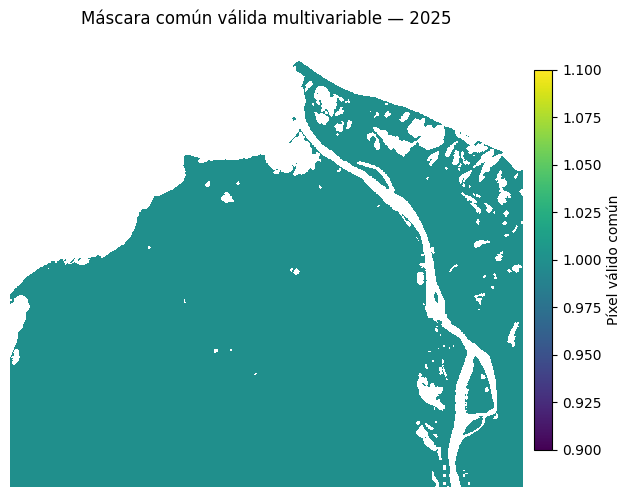

Figura guardada: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/figures/03_qc_lst_masked_selected_years_2013_2025.png


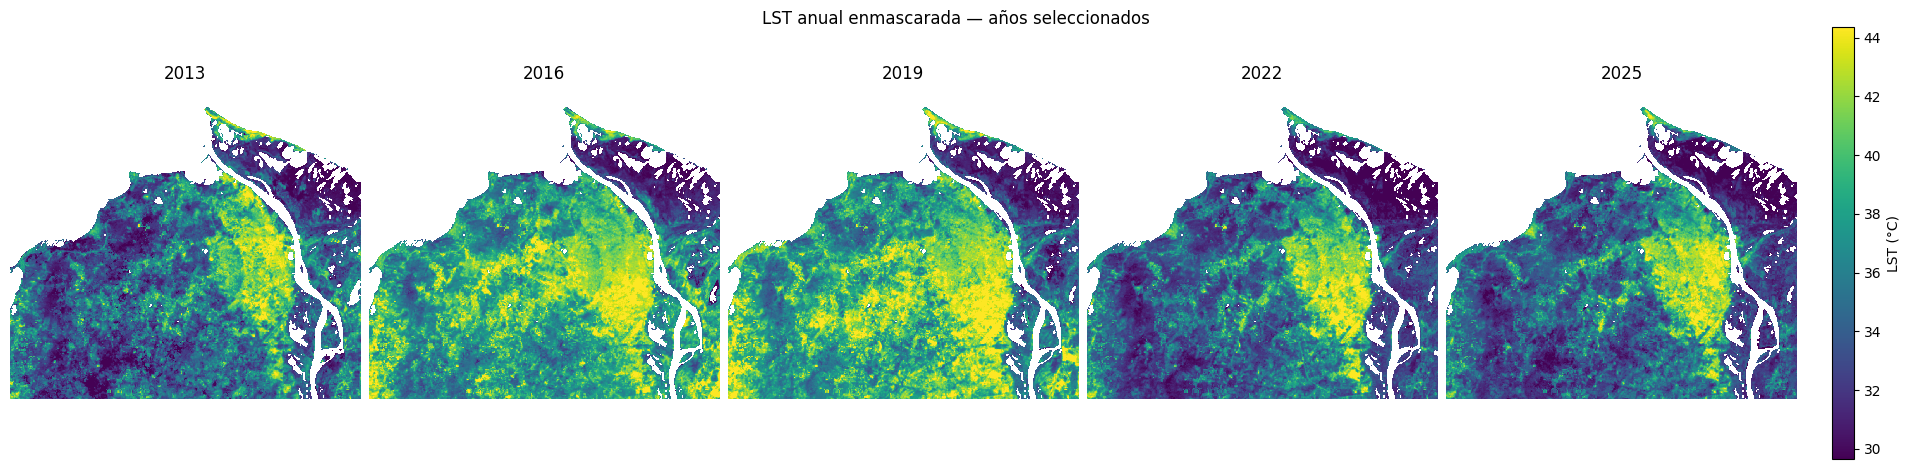

Figura guardada: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/figures/03_qc_common_valid_coverage_by_year_2013_2025.png


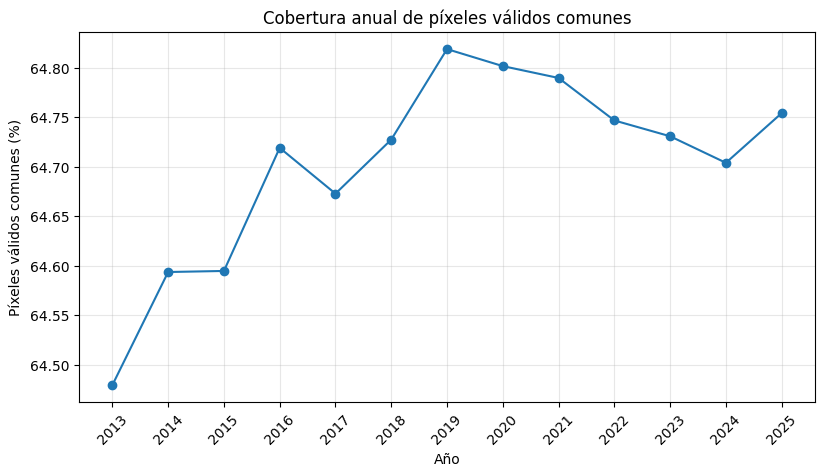

Directorio de figuras: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/figures


In [12]:
# ============================================================
# CELDA 12 — Salidas gráficas de auditoría
# ============================================================

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_YEARS_LST = [2013, 2016, 2019, 2022, 2025]
SELECTED_YEARS_LST = [y for y in SELECTED_YEARS_LST if y in YEARS]


def _read_float_raster(path: Path):
    """Leer un raster continuo y devolverlo como float32 con NoData convertido a NaN."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr[arr == -9999.0] = np.nan
    return arr


def _save_current_figure(path: Path, dpi: int = 180):
    """Guardar figura activa en PNG con márgenes ajustados."""
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Figura guardada: {path}")


# ------------------------------------------------------------
# 12.1. Figura de máscara común válida / dominio final
# ------------------------------------------------------------

common_mask_dir = PROJECT_DIR / "04_quality_masks" / "common_valid_mask"
mask_candidates = [
    common_mask_dir / f"EXP10Bv6_common_valid_mask_{END_YEAR}.tif",
    common_mask_dir / f"EXP10Bv6_common_valid_mask_{SUPPORT_YEAR}.tif",
]
mask_candidates += sorted(common_mask_dir.glob("EXP10Bv6_common_valid_mask_*.tif"))
mask_path = next((p for p in mask_candidates if p.exists()), None)

if mask_path is None:
    print("No se encontró una máscara común válida V6 para graficar.")
else:
    with rasterio.open(mask_path) as src:
        mask_arr = src.read(1)
    mask_year = int(mask_path.stem.split("_")[-1])
    mask_show = np.where(mask_arr == 1, 1, np.nan)

    plt.figure(figsize=(7.0, 7.0))
    plt.imshow(mask_show, interpolation="nearest")
    plt.title(f"Máscara común válida multivariable — {mask_year}")
    plt.axis("off")
    cbar = plt.colorbar(fraction=0.035, pad=0.02)
    cbar.set_label("Píxel válido común")
    _save_current_figure(FIG_DIR / f"03_qc_common_valid_mask_{mask_year}.png")
    plt.show()


# ------------------------------------------------------------
# 12.2. Panel de LST anual enmascarada para años seleccionados
# ------------------------------------------------------------

lst_arrays = {}
for year in SELECTED_YEARS_LST:
    lst_path = V6_DIR / expected_filename("v6", "LST", year)
    if lst_path.exists():
        lst_arrays[year] = _read_float_raster(lst_path)
    else:
        print(f"No se encontró LST V6 para {year}: {lst_path}")

if not lst_arrays:
    print("No hay mapas LST V6 disponibles para construir el panel gráfico.")
else:
    valid_value_blocks = [arr[np.isfinite(arr)].ravel() for arr in lst_arrays.values() if np.isfinite(arr).any()]
    if not valid_value_blocks:
        print("Los mapas LST seleccionados no contienen valores válidos.")
    else:
        all_values = np.concatenate(valid_value_blocks)
        vmin, vmax = np.nanpercentile(all_values, [2, 98])
        n = len(lst_arrays)
        fig, axes = plt.subplots(1, n, figsize=(3.8 * n, 4.4), constrained_layout=True)
        if n == 1:
            axes = [axes]

        last_im = None
        for ax, (year, arr) in zip(axes, lst_arrays.items()):
            last_im = ax.imshow(arr, vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(str(year))
            ax.axis("off")

        cbar = fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
        cbar.set_label("LST (°C)")
        fig.suptitle("LST anual enmascarada — años seleccionados", y=1.03)
        _save_current_figure(FIG_DIR / "03_qc_lst_masked_selected_years_2013_2025.png")
        plt.show()


# ------------------------------------------------------------
# 12.3. Cobertura válida común por año
# ------------------------------------------------------------

coverage_df = None
if "v6_year_qc_df" in globals():
    coverage_df = v6_year_qc_df.copy()
else:
    coverage_csv = OUT_DIR / "03_qc_v6_common_valid_by_year_2013_2025.csv"
    if coverage_csv.exists():
        coverage_df = pd.read_csv(coverage_csv)

if coverage_df is None or coverage_df.empty:
    print("No hay tabla de cobertura V6 disponible para graficar.")
elif "year" not in coverage_df.columns or "pct_valid_all" not in coverage_df.columns:
    print("La tabla de cobertura no contiene las columnas esperadas: year, pct_valid_all.")
else:
    coverage_df = coverage_df.sort_values("year")
    plt.figure(figsize=(9.5, 4.8))
    plt.plot(coverage_df["year"], coverage_df["pct_valid_all"], marker="o")
    plt.title("Cobertura anual de píxeles válidos comunes")
    plt.xlabel("Año")
    plt.ylabel("Píxeles válidos comunes (%)")
    plt.xticks(coverage_df["year"].astype(int), rotation=45)
    plt.grid(True, alpha=0.3)
    _save_current_figure(FIG_DIR / "03_qc_common_valid_coverage_by_year_2013_2025.png")
    plt.show()

print("Directorio de figuras:", FIG_DIR)




In [13]:
# ============================================================
# CELDA 13 — Resumen final y estado para revisión
# ============================================================

summary_rows = []

summary_rows.append({
    "item": "operational_period",
    "value": f"{START_YEAR}-{END_YEAR}",
})
summary_rows.append({
    "item": "expected_v3_files",
    "value": EXPECTED_TOTAL_FILES,
})
summary_rows.append({
    "item": "found_v3_files",
    "value": len(found_v3),
})
summary_rows.append({
    "item": "missing_v3_files",
    "value": len(missing_v3),
})
summary_rows.append({
    "item": "v3_all_files_present",
    "value": len(missing_v3) == 0,
})
summary_rows.append({
    "item": "v3_all_geom_ref_ok",
    "value": bool(v3_audit_df["geom_ref_ok"].all()),
})
summary_rows.append({
    "item": "apply_structural_T30_mask",
    "value": APPLY_STRUCTURAL_T30_MASK,
})
summary_rows.append({
    "item": "apply_final_domain",
    "value": APPLY_FINAL_DOMAIN,
})
summary_rows.append({
    "item": "build_common_valid_mask",
    "value": BUILD_COMMON_VALID_MASK,
})

if BUILD_COMMON_VALID_MASK:
    summary_rows.append({
        "item": "v6_all_status_approved",
        "value": bool((v6_year_qc_df["status"] == "approved").all()),
    })
    summary_rows.append({
        "item": "v6_total_mismatch_pixels",
        "value": int(v6_year_qc_df["n_mismatch"].sum()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = OUT_DIR / "03_quality_control_summary_2013_2025.csv"
summary_json = OUT_DIR / "03_quality_control_summary_2013_2025.json"

summary_df.to_csv(summary_csv, index=False)
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump({row["item"]: row["value"] for _, row in summary_df.iterrows()}, f, indent=2, ensure_ascii=False)

print("=" * 80)
print("ESTADO FINAL — NOTEBOOK 03 CONTROL DE CALIDAD")
print("=" * 80)
print("Summary CSV :", summary_csv)
print("Summary JSON:", summary_json)
print("QC output directory:", OUT_DIR)

display(summary_df)

if len(missing_v3) == 0 and (not BUILD_COMMON_VALID_MASK or (v6_year_qc_df["status"] == "approved").all()):
    print("\nRESULTADO: CONTROL DE CALIDAD APROBADO para la configuración ejecutada.")
else:
    print("\nRESULTADO: EL CONTROL DE CALIDAD REQUIERE REVISIÓN. Revise los reportes CSV generados.")


ESTADO FINAL — NOTEBOOK 03 CONTROL DE CALIDAD
Summary CSV : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/03_quality_control_summary_2013_2025.csv
Summary JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025/03_quality_control_summary_2013_2025.json
QC output directory: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/03_quality_control_2013_2025


,item,value
0,operational_period,2013-2025
1,expected_v3_files,117
2,found_v3_files,126
3,missing_v3_files,0
4,v3_all_files_present,True
5,v3_all_geom_ref_ok,False
6,apply_structural_T30_mask,True
7,apply_final_domain,True
8,build_common_valid_mask,True
9,v6_all_status_approved,True



RESULTADO: CONTROL DE CALIDAD APROBADO para la configuración ejecutada.


## Salidas esperadas

Después de una ejecución exitosa, este notebook produce:

- reportes CSV de control de calidad en `00_documentation/quality_control/03_quality_control_2013_2025/`;
- productos anuales con máscara estructural en `03_annual_raw_composites/v4_T30_structural_land/`, si está habilitado;
- productos anuales con dominio final en `03_annual_raw_composites/v5_final_domain/`, si está habilitado;
- productos anuales con máscara común válida en `03_annual_raw_composites/v6_common_valid_mask/`, si está habilitado;
- máscaras diagnósticas en `04_quality_masks/final_land_domain/` y `04_quality_masks/common_valid_mask/`;
- figuras PNG de auditoría en `00_documentation/quality_control/03_quality_control_2013_2025/figures/`.

Los GeoTIFF generados son productos pesados y **no deben subirse a GitHub**. Solo el notebook y los reportes CSV ligeros pueden incorporarse si aportan valor para la revisión.

